# About The Data

In [1]:
import pandas as pd
import numpy as np

data_file_path = "../data/MNIST_CSV/mnist_test.csv"

df = pd.read_csv(data_file_path)

df.head(5)

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
Y = df.iloc[0:, 0:1]
x = df.iloc[0:, 1:] / 255

x = x.to_numpy()
Y = Y.to_numpy()
print(x.shape, Y.shape)

(9999, 784) (9999, 1)


In [3]:
Y_1d = Y.flatten()

import pandas as pd
import matplotlib.pyplot as plt

y_series = pd.Series(Y_1d)
y_counts = y_series.value_counts().sort_index()

In [4]:
y_counts

0     980
1    1135
2    1032
3    1010
4     982
5     892
6     958
7    1027
8     974
9    1009
Name: count, dtype: int64

In [5]:
y_counts.sum()

np.int64(9999)

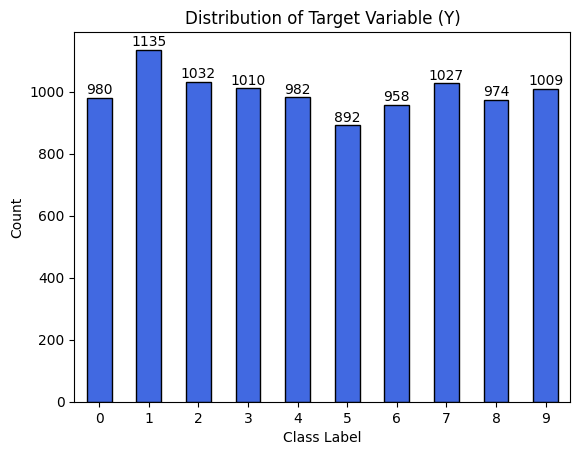

In [6]:
y_counts.plot(kind='bar', color='royalblue', edgecolor='black')

for i, count in enumerate(y_counts):
    plt.text(i, count + (max(y_counts)*0.01), str(count), ha='center')

plt.title("Distribution of Target Variable (Y)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Check The Data

In [7]:
x = x.reshape(9999, 1, 28, 28)

nb_classes = 10
one_hot_targets = np.eye(nb_classes)[Y]
one_hot_targets = one_hot_targets.reshape(one_hot_targets.shape[0], -1)

In [8]:
x.shape, one_hot_targets.shape

((9999, 1, 28, 28), (9999, 10))

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


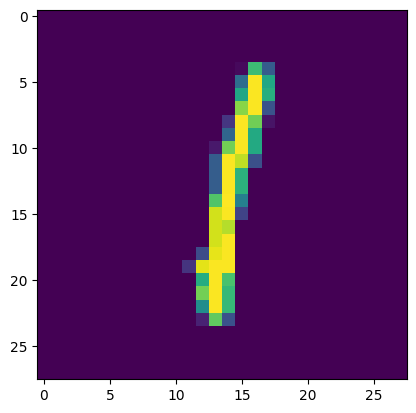

In [9]:
from matplotlib import pyplot as plt

random_choice = np.random.randint(0, 5999)
print(one_hot_targets[random_choice])
plt.imshow(x[random_choice][0])
plt.show()

# Random Sampling Data Each Label

In [10]:
import numpy as np
import pandas as pd

n_samples = 100

y_series = pd.Series(Y.flatten())

random_indices = (
    y_series.groupby(y_series)
    .apply(lambda x: x.sample(n=n_samples, random_state=42))
    .index.get_level_values(1)
)

x_sampled = x[random_indices]
Y_sampled = Y[random_indices]

print("Dimensi X baru:", x_sampled.shape)
print("Dimensi Y baru:", Y_sampled.shape)

Dimensi X baru: (1000, 1, 28, 28)
Dimensi Y baru: (1000, 1)


# Export Data as Hex

In [11]:
import numpy as np

def generate_mem_files(pixel_data, label, file_index):
    
    flat_data = pixel_data.reshape(-1)
    folder_path = f"./image-hex-gen-test/mnist_img_{label}"
    file_path = f"{folder_path}/img_{file_index}.mem"
    
    with open(file_path, "w") as f:
        for pixel in flat_data:
            val = int(np.clip(pixel * 255, 0, 255))
            f.write(f"{val:02X}\n")


In [12]:
Y_labels = Y_sampled.flatten()

for i in range(len(x_sampled)):
    current_image = x_sampled[i]
    current_label = Y_labels[i]
    
    generate_mem_files(current_image, current_label, file_index=i)

print(f"Selesai! Semua file .mem untuk {len(x_sampled)} sampel gambar telah dibuat.")


Selesai! Semua file .mem untuk 1000 sampel gambar telah dibuat.


# Combine All Image Input By Label

In [13]:
import os

folder_path = "./image-hex-gen-test/mnist_img_"
parent_folder = './image-hex-gen-test/'

for i in range(10):
    folder_path_by_label = f"{folder_path}{i}/"
    
    mem_files = [os.path.join(folder_path_by_label, filename) for filename in os.listdir(folder_path_by_label) if filename.endswith('.mem')]
    
    output_file_path = os.path.join(parent_folder, f"combined_mnist_{i}.mem")
    
    with open(output_file_path, 'w') as outfile:
        for file_path in mem_files:
            with open(file_path, 'r') as infile:
                outfile.write(infile.read())
                outfile.write("\n")
                
    print(f"Berhasil menggabungkan {len(mem_files)} file untuk Label {i} -> {output_file_path}")

Berhasil menggabungkan 100 file untuk Label 0 -> ./image-hex-gen-test/combined_mnist_0.mem
Berhasil menggabungkan 100 file untuk Label 1 -> ./image-hex-gen-test/combined_mnist_1.mem
Berhasil menggabungkan 100 file untuk Label 2 -> ./image-hex-gen-test/combined_mnist_2.mem
Berhasil menggabungkan 100 file untuk Label 3 -> ./image-hex-gen-test/combined_mnist_3.mem
Berhasil menggabungkan 100 file untuk Label 4 -> ./image-hex-gen-test/combined_mnist_4.mem
Berhasil menggabungkan 100 file untuk Label 5 -> ./image-hex-gen-test/combined_mnist_5.mem
Berhasil menggabungkan 100 file untuk Label 6 -> ./image-hex-gen-test/combined_mnist_6.mem
Berhasil menggabungkan 100 file untuk Label 7 -> ./image-hex-gen-test/combined_mnist_7.mem
Berhasil menggabungkan 100 file untuk Label 8 -> ./image-hex-gen-test/combined_mnist_8.mem
Berhasil menggabungkan 100 file untuk Label 9 -> ./image-hex-gen-test/combined_mnist_9.mem
